In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import statsmodels.stats.multitest
import umap

import celltrip


mpl.rcParams['pdf.fonttype'] = 42


2026-03-26 21:47:07.462395: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load Data

In [ ]:
# Read data
adata_atac_intersection, = celltrip.utility.processing.read_adatas('s3://nkalafut-celltrip/NHP/top5k_peaks_intersection.h5ad')
adata_exp_intersection, = celltrip.utility.processing.read_adatas('s3://nkalafut-celltrip/ExpVal/expression_intersection.h5ad')

# Correct variables
for adata in [adata_atac_intersection, adata_exp_intersection]:
    adata.obs['age_orig'] = adata.obs['age']
    adata.obs['age'] = adata.obs['age'].apply(lambda x: {  # Translate ages (TODO: Verify that this is correct)
        k: v for k, v in zip(
            ['E87', 'E96', 'E101', 'E104', 'E112', 'E127', 'E150', 'E155'],
            (85, 95, 100, 105, 110, 125, 145, 155))}[x])
    adata.obs['subtype_orig'] = adata.obs['subtype']
    adata.obs['subtype'] = adata.obs['subtype'].map(lambda s: ' '.join(s.split(' ')[:2]), na_action='ignore')  # Shorten subtypes

# Normalize data for visualization
sim_data = adata_exp_intersection.X[:].tocsr()
sim_data_norm = (10_000 * sim_data / sim_data.sum(axis=1)).tocsr()
sim_data_norm_train = sim_data_norm[(~adata_exp_intersection.obs['Train']).to_numpy()]
sim_data_norm_train_dense = np.array(sim_data_norm_train.todense())
adata_atac_val = adata_atac_intersection[~adata_atac_intersection.obs['Train']]
adata_exp_val = adata_exp_intersection[~adata_exp_intersection.obs['Train']]


In [8]:
# Load manager
prefix, training_step = 's3://nkalafut-celltrip/checkpoints/ExpVal-NHP-260326', 800
manager = celltrip.manager.BasicManager(
    policy_fname=f'{prefix}-{training_step:04}.weights',
    preprocessing_fname=f'{prefix}.pre',
    mask_fname=f'{prefix}.mask',
    device='cuda')

# Use validation, unpartitioned data
manager.set_modalities([adata_atac_val], suppress_warning=True)


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

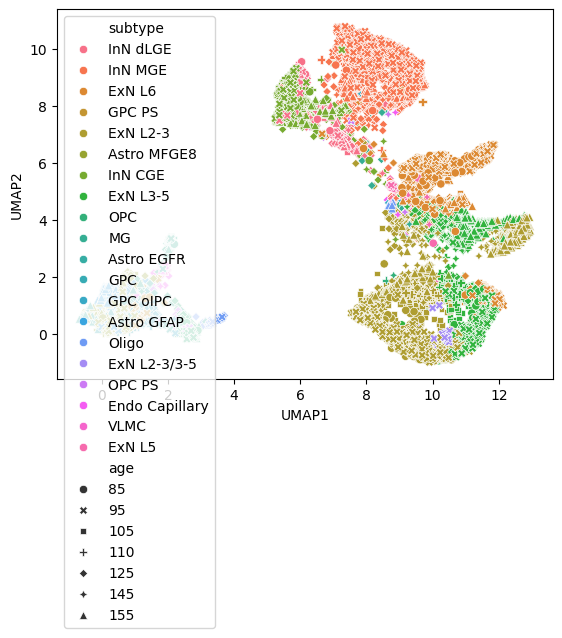

In [27]:
# Plot
orig_red = umap.UMAP(n_neighbors=200)
orig_emb = orig_red.fit_transform(sim_data_norm_train)
df = pd.DataFrame(orig_emb, columns=['UMAP1', 'UMAP2'], index=adata_atac_val.obs_names)
df['age'] = adata_atac_val.obs['age']
df['subtype'] = adata_atac_val.obs['subtype']
df['sample'] = adata_atac_val.obs['sample']
ax = sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue='subtype', style='age')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))


# Simulate

In [10]:
# Simulate to steady state
manager.reset_env()
manager.simulate(skip_time=512., impute=False)
manager.save_state('steady')
steady_gex, = manager.get_state()

100%|██████████| 5120/5120 [03:05<00:00, 27.55it/s]


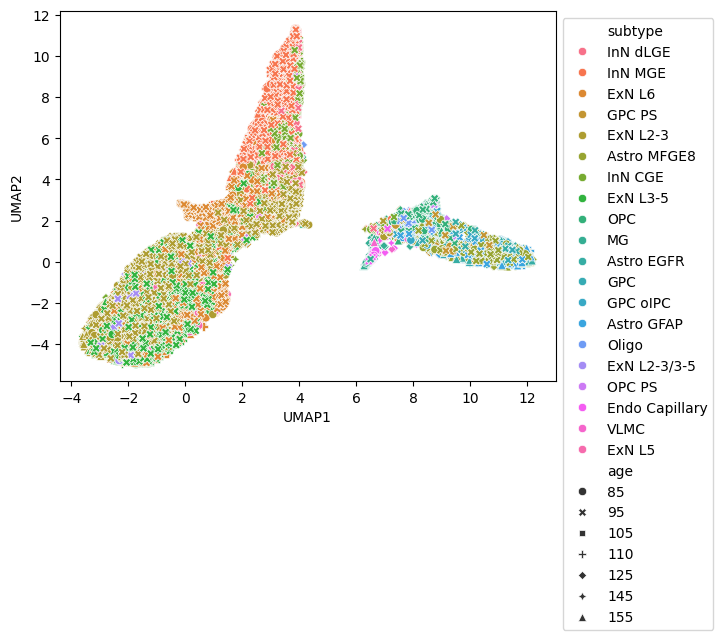

In [29]:
# Plot
steady_red = umap.UMAP(n_neighbors=200)
steady_emb = steady_red.fit_transform(steady_gex)
df = pd.DataFrame(steady_emb, columns=['UMAP1', 'UMAP2'], index=adata_atac_val.obs_names)
df['age'] = adata_atac_val.obs['age']
df['subtype'] = adata_atac_val.obs['subtype']
df['sample'] = adata_atac_val.obs['sample']
ax = sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue='subtype', style='age')
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1))


In [11]:
# Plot kwargs
point_kwargs = {'alpha': 0.1, 's': 5}

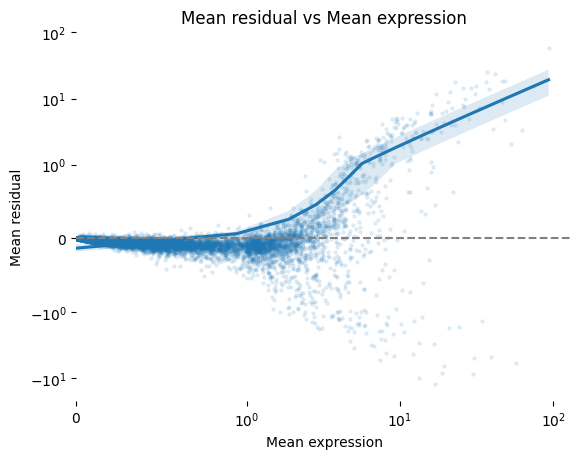

In [28]:
# Plot mean residual vs mean expression for each gene
residuals = np.array(steady_gex) - np.array(sim_data_norm_train.todense())
residuals_mean = residuals.mean(axis=0)
expression_mean = sim_data_norm_train_dense.mean(axis=0)
plt.scatter(expression_mean, residuals_mean, **point_kwargs)
sns.regplot(x=expression_mean, y=residuals_mean, order=1, scatter=False, label='Residual Trend')
plt.xlabel('Mean expression')
plt.ylabel('Mean residual')
plt.title('Mean residual vs Mean expression')
plt.xscale('symlog', linthresh=1)
plt.yscale('symlog', linthresh=1)
plt.xlim(left=0)
plt.axhline(0, color='gray', linestyle='--')
sns.despine(left=True, bottom=True)
# NOTE: Tends to overestimate genes with higher mean residuals

/tmp/ipykernel_2942/2025737182.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_correlations, pearson_p_values = np.stack([scipy.stats.pearsonr(steady_gex[:, i], sim_data_norm_train_dense[:, i]) for i in range(steady_gex.shape[1])]).T
/tmp/ipykernel_2942/2025737182.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_correlations, spearman_p_values = np.stack([scipy.stats.spearmanr(steady_gex[:, i], sim_data_norm_train_dense[:, i]) for i in range(steady_gex.shape[1])]).T


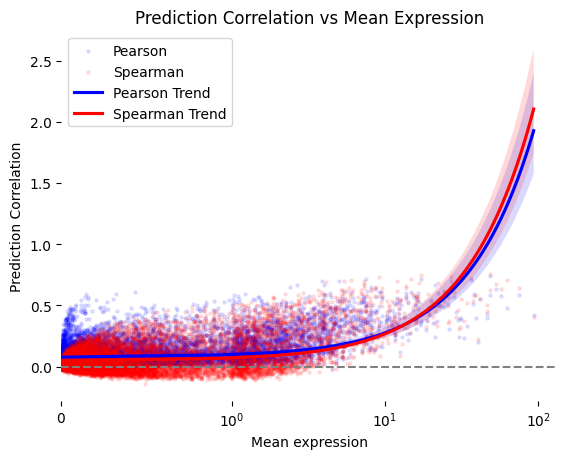

In [ ]:
# Gather correlation and p-values between prediction and truth for each gene using pearson and spearman correlation
pearson_correlations, pearson_p_values = np.stack([scipy.stats.pearsonr(steady_gex[:, i], sim_data_norm_train_dense[:, i]) for i in range(steady_gex.shape[1])]).T
spearman_correlations, spearman_p_values = np.stack([scipy.stats.spearmanr(steady_gex[:, i], sim_data_norm_train_dense[:, i]) for i in range(steady_gex.shape[1])]).T

# Remove zero values
nan_mask = np.isnan(pearson_correlations)
pearson_correlations, pearson_p_values = pearson_correlations[~nan_mask], pearson_p_values[~nan_mask]
spearman_correlations, spearman_p_values = spearman_correlations[~nan_mask], spearman_p_values[~nan_mask]

# Compute benjamini-hochberg FDR for pearson and spearman p-values
pearson_fdr = statsmodels.stats.multitest.multipletests(pearson_p_values, method='fdr_bh')[1]
spearman_fdr = statsmodels.stats.multitest.multipletests(spearman_p_values, method='fdr_bh')[1]

# Plot correlations vs mean expression
plt.scatter(expression_mean[~nan_mask], pearson_correlations, color='blue', label='Pearson', **point_kwargs)
plt.scatter(expression_mean[~nan_mask], spearman_correlations, color='red', label='Spearman', **point_kwargs)
plt.axhline(0, color='gray', linestyle='--')

# Trend lines
sns.regplot(x=expression_mean[~nan_mask], y=pearson_correlations, order=1, scatter=False, color='blue', label='Pearson Trend')
sns.regplot(x=expression_mean[~nan_mask], y=spearman_correlations, order=1, scatter=False, color='red', label='Spearman Trend')

# Labels
plt.xlabel('Mean expression')
plt.ylabel('Prediction Correlation')
plt.title('Prediction Correlation vs Mean Expression')
plt.xscale('symlog', linthresh=1)
plt.xlim(left=0)

# Graphics
sns.despine(left=True, bottom=True)
plt.legend()

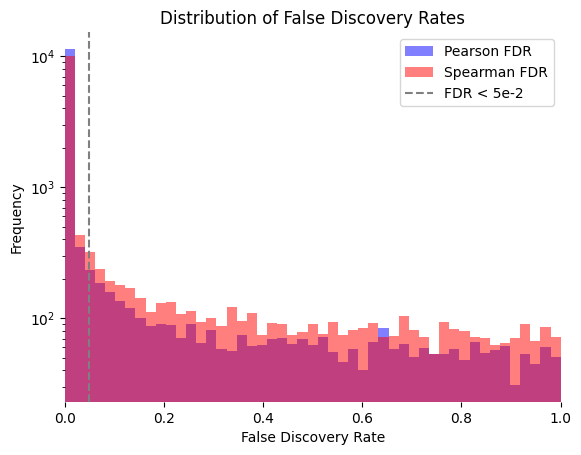

In [ ]:
# Plot histogram of false discovery rates
bins = np.linspace(0, 1, 50)
plt.hist(pearson_fdr, bins, color='blue', alpha=0.5, label='Pearson FDR')
plt.hist(spearman_fdr, bins, color='red', alpha=0.5, label='Spearman FDR')
plt.axvline(0.05, color='gray', linestyle='--', label='FDR < 5e-2')
plt.xlabel('False Discovery Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Gene Correlation False Discovery Rates')
plt.yscale('symlog', linthresh=1)
plt.ylim(bottom=0)
sns.despine(left=True, bottom=True)
plt.xlim(0, 1)
plt.legend()

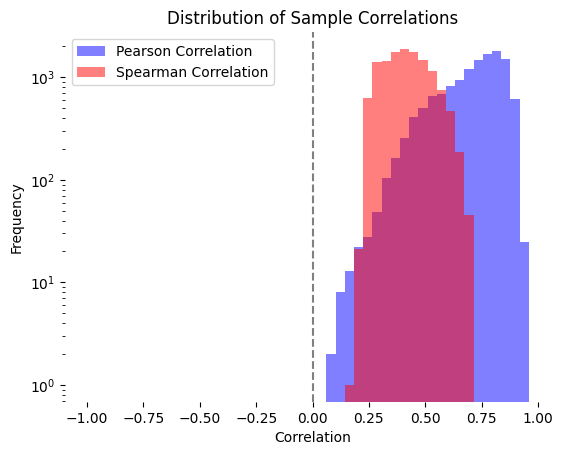

In [ ]:
# Calculate per-sample correlation and p-values
pearson_correlations, pearson_p_values = np.stack([scipy.stats.pearsonr(steady_gex[i, :], sim_data_norm_train_dense[i, :]) for i in range(steady_gex.shape[0])]).T
spearman_correlations, spearman_p_values = np.stack([scipy.stats.spearmanr(steady_gex[i, :], sim_data_norm_train_dense[i, :]) for i in range(steady_gex.shape[0])]).T

# Compute benjamini-hochberg FDR for pearson and spearman p-values
pearson_fdr = statsmodels.stats.multitest.multipletests(pearson_p_values, method='fdr_bh')[1]
spearman_fdr = statsmodels.stats.multitest.multipletests(spearman_p_values, method='fdr_bh')[1]

# Plot histogram of correlation
bins = np.linspace(-1, 1, 50)
plt.hist(pearson_correlations, bins, color='blue', alpha=0.5, label='Pearson Correlation')
plt.hist(spearman_correlations, bins, color='red', alpha=0.5, label='Spearman Correlation')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Correlations')
plt.yscale('symlog', linthresh=1)
plt.ylim(bottom=0)
sns.despine(left=True, bottom=True)
plt.legend()


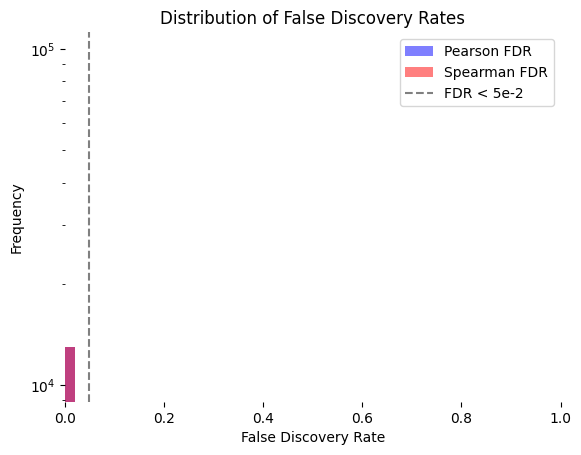

In [ ]:
# Plot histogram of false discovery rates
bins = np.linspace(0, 1, 50)
plt.hist(pearson_fdr, bins, color='blue', alpha=0.5, label='Pearson FDR')
plt.hist(spearman_fdr, bins, color='red', alpha=0.5, label='Spearman FDR')
plt.axvline(0.05, color='gray', linestyle='--', label='FDR < 5e-2')
plt.xlabel('False Discovery Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Sample Correlation False Discovery Rates')
plt.yscale('symlog', linthresh=1)
sns.despine(left=True, bottom=True)
plt.xlim(0, 1)
plt.ylim(bottom=0)
plt.legend()

# Gene Verification

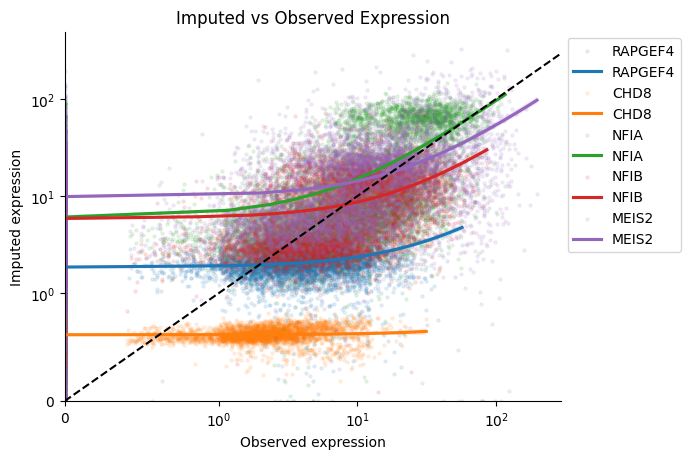

In [38]:
# Parameters
genes_of_interest = ['RAPGEF4', 'CHD8', 'NFIA', 'NFIB', 'MEIS2']

# Scatterplot of imputed expression vs observed for genes of interest
for gene in genes_of_interest:
    gene_idx = adata_exp_intersection.var_names.get_loc(gene)
    plt.scatter(sim_data_norm_train_dense[:, gene_idx], steady_gex[:, gene_idx], **point_kwargs, label=gene)
    sns.regplot(x=sim_data_norm_train_dense[:, gene_idx], y=steady_gex[:, gene_idx], order=1, scatter=False, label=gene)

# Labels
plt.xlabel('Observed expression')
plt.ylabel('Imputed expression')
plt.title(f'Imputed vs Observed Expression')
plt.xscale('symlog', linthresh=1)
plt.yscale('symlog', linthresh=1)

# Viewing
plt.xlim(left=0)
plt.ylim(bottom=0)
sns.despine()
plt.legend()
sns.move_legend(plt.gca(), 'upper left', bbox_to_anchor=(1, 1))

# Add line y=x for reference
lims = [min(sim_data_norm_train_dense.min(), steady_gex.min()), max(sim_data_norm_train_dense.max(), steady_gex.max())]
plt.plot(lims, lims, color='black', linestyle='--', label='Ideal fit')


# Knockdown

In [ ]:
# Get control
manager.reset_env()
manager.load_state('steady')
manager.simulate_perturbation(skip_time=512., time=128., impute=False)
control_gex, = manager.get_state()


100%|██████████| 1280/1280 [00:46<00:00, 27.24it/s]


In [ ]:
# Plot
control_red = umap.UMAP(n_neighbors=200)
control_emb = control_red.fit_transform(control_gex)
df = pd.DataFrame(control_emb, columns=['UMAP1', 'UMAP2'], index=adata_atac_val.obs_names)
df['age'] = adata_atac_val.obs['age']
df['subtype'] = adata_atac_val.obs['subtype']
df['sample'] = adata_atac_val.obs['sample']
sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue='subtype', style='age')


In [ ]:
# Perform knockdown
manager.reset_env()
manager.load_state('steady')
manager.add_perturbation(['SOME_FEATURE'], modality=0, feature_targets=0)  # TODO
manager.simulate_perturbation(skip_time=512., time=128., impute=False)
pert_gex, = manager.get_state()

In [ ]:
# Plot
control_emb = control_red.transform(pert_gex)
df = pd.DataFrame(control_emb, columns=['UMAP1', 'UMAP2'], index=adata_atac_val.obs_names)
df['age'] = adata_atac_val.obs['age']
df['subtype'] = adata_atac_val.obs['subtype']
df['sample'] = adata_atac_val.obs['sample']
sns.scatterplot(data=df, x='UMAP1', y='UMAP2', hue='subtype', style='age')
